In [80]:
import numpy as np
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
from mlxtend.plotting import plot_decision_regions
import matplotlib.pyplot as plt
import time
from sklearn.tree import plot_tree

In [81]:
class Node:
    def __init__(self,feature = None,threshold = None,left = None , right = None,*,value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

    def is_leaf_node(self):
        return self.value is not None


class DecisionTree:
    def __init__(self,min_samples_split=2,max_depth = 100,n_features = None):
        self.min_samples_split = min_samples_split
        self.max_depth = max_depth
        self.n_features = n_features
        self.root = None

    def fit(self,x_train,y_train):
        self.n_features = x_train.shape[1] if not self.n_features else min(x_train.shape[1],self.n_features)
        self.root = self.grow_tree(x_train,y_train)

    def grow_tree(self,x,y,depth=0):
        n_samples,n_feats = x.shape
        n_labels = len(np.unique(y))

        #Check stopping criteria:
        if (depth>=self.max_depth or n_labels == 1 or n_samples < self.min_samples_split):
            leaf_value = self.most_common(y)
            return Node(value=leaf_value)
        
        #Finding best split:
        feat_idx = np.random.choice(n_feats,self.n_features,replace = False)
        best_feat,best_thr = self.best_split(x,y,feat_idx)

        # child nodes:
        left_idxs , right_idxs = self._split(x[:,best_feat],best_thr)
        left = self.grow_tree(x[left_idxs,:],y[left_idxs],depth+1)
        right = self.grow_tree(x[right_idxs,:],y[right_idxs],depth+1)

        return Node(best_feat,best_thr,left,right)

    def best_split(self,x,y,feat_idx):
        best_gain = -1
        split_idx,split_thr = None,None

        for feat_id in feat_idx:
            x_column = x[:,feat_id]
            thresholds = np.unique(x_column)

            for thr in thresholds:
                gain = self.info_gain(y,x_column,thr)

                if gain>best_gain:
                    best_gain = gain
                    split_idx = feat_id
                    split_thr = thr

        return split_idx,split_thr
    def most_common(self,y):
        count = Counter(y)
        
        return count.most_common(1)[0][0]
    
    def info_gain(self,y,x_column,threshold):
        #parent entropy:
        parent_entropy = self.entropy(y)
        
        #create children:
        left_idxs,right_idxs = self._split(x_column,threshold)

        if len(left_idxs)== 0 or len(right_idxs)== 0 :
            return 0
        
        #weighted avg.entropy of children:
        n = len(y)
        n_l,n_r = len(left_idxs),len(right_idxs)
        e_l,e_r = self.entropy(y[left_idxs]) , self.entropy(y[right_idxs])
        child_entropy = (n_l/n)*e_l + (n_r/n)*e_r

        info_gain = parent_entropy - child_entropy
        return info_gain

    def entropy(self,y):
        hist = np.bincount(y)
        ps= hist/len(y)
        return -np.sum([p * np.log2(p) for p in ps if p > 0])
    
    def _split(self,x_column,split_thresh):
        left_idxs = np.argwhere(x_column <= split_thresh).flatten()
        right_idxs = np.argwhere(x_column > split_thresh).flatten()

        return left_idxs,right_idxs
    
    def predict(self,x_test):
        return np.array([self._traverse_tree(x,self.root) for x in x_test])
    
    def _traverse_tree(self,x,node):
        if node.is_leaf_node():
            return node.value
        
        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x,node.left)
        
        return self._traverse_tree(x,node.right)

In [82]:
from sklearn.datasets import load_wine
df = load_wine()
x = df.data
y = df.target

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)


In [83]:
dt = DecisionTree()
start = time.time()
dt.fit(x_train,y_train)
print(f"time took : {time.time()-start} s")

time took : 0.42255640029907227 s


In [84]:
y_pred = dt.predict(x_test)
dt_acc = accuracy_score(y_test,y_pred)

In [85]:
clf = DecisionTreeClassifier(max_depth=100,criterion='entropy')
clf.fit(x_train,y_train)
clf_acc = accuracy_score(y_test,clf.predict(x_test))

In [86]:
# Difference in accuracy :
clf_acc - dt_acc

0.0

# For visualization of decision boundary in 2-D (using PCA)

In [87]:
def visualize_DB(max_depth = 100 ):
    pca = PCA(n_components=2)
    x_train_pca = pca.fit_transform(x_train)
    x_test_pca = pca.transform(x_test)
    dt_pca = DecisionTree(max_depth=max_depth)
    dt_pca.fit(x_train_pca,y_train)

    plt.figure(figsize=(12,6))
    plt.subplot(121)
    plot_decision_regions(x_train_pca,y_train,dt_pca)
    acc_train = accuracy_score(y_train,dt_pca.predict(x_train))
    plt.title(f"Training set (Acc = {acc_train})")
    plt.subplot(122)
    plot_decision_regions(x_test_pca,y_test,dt_pca)
    acc_test = accuracy_score(y_test,dt_pca.predict(x_test))
    plt.title(f"Test set (Acc = {acc_test})")

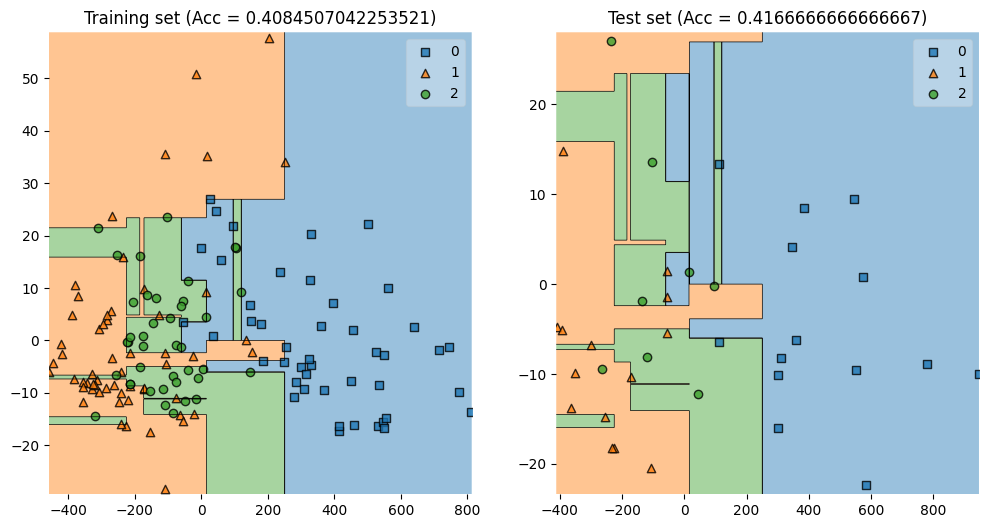

In [88]:
visualize_DB(50)

# Decision tree visualization:

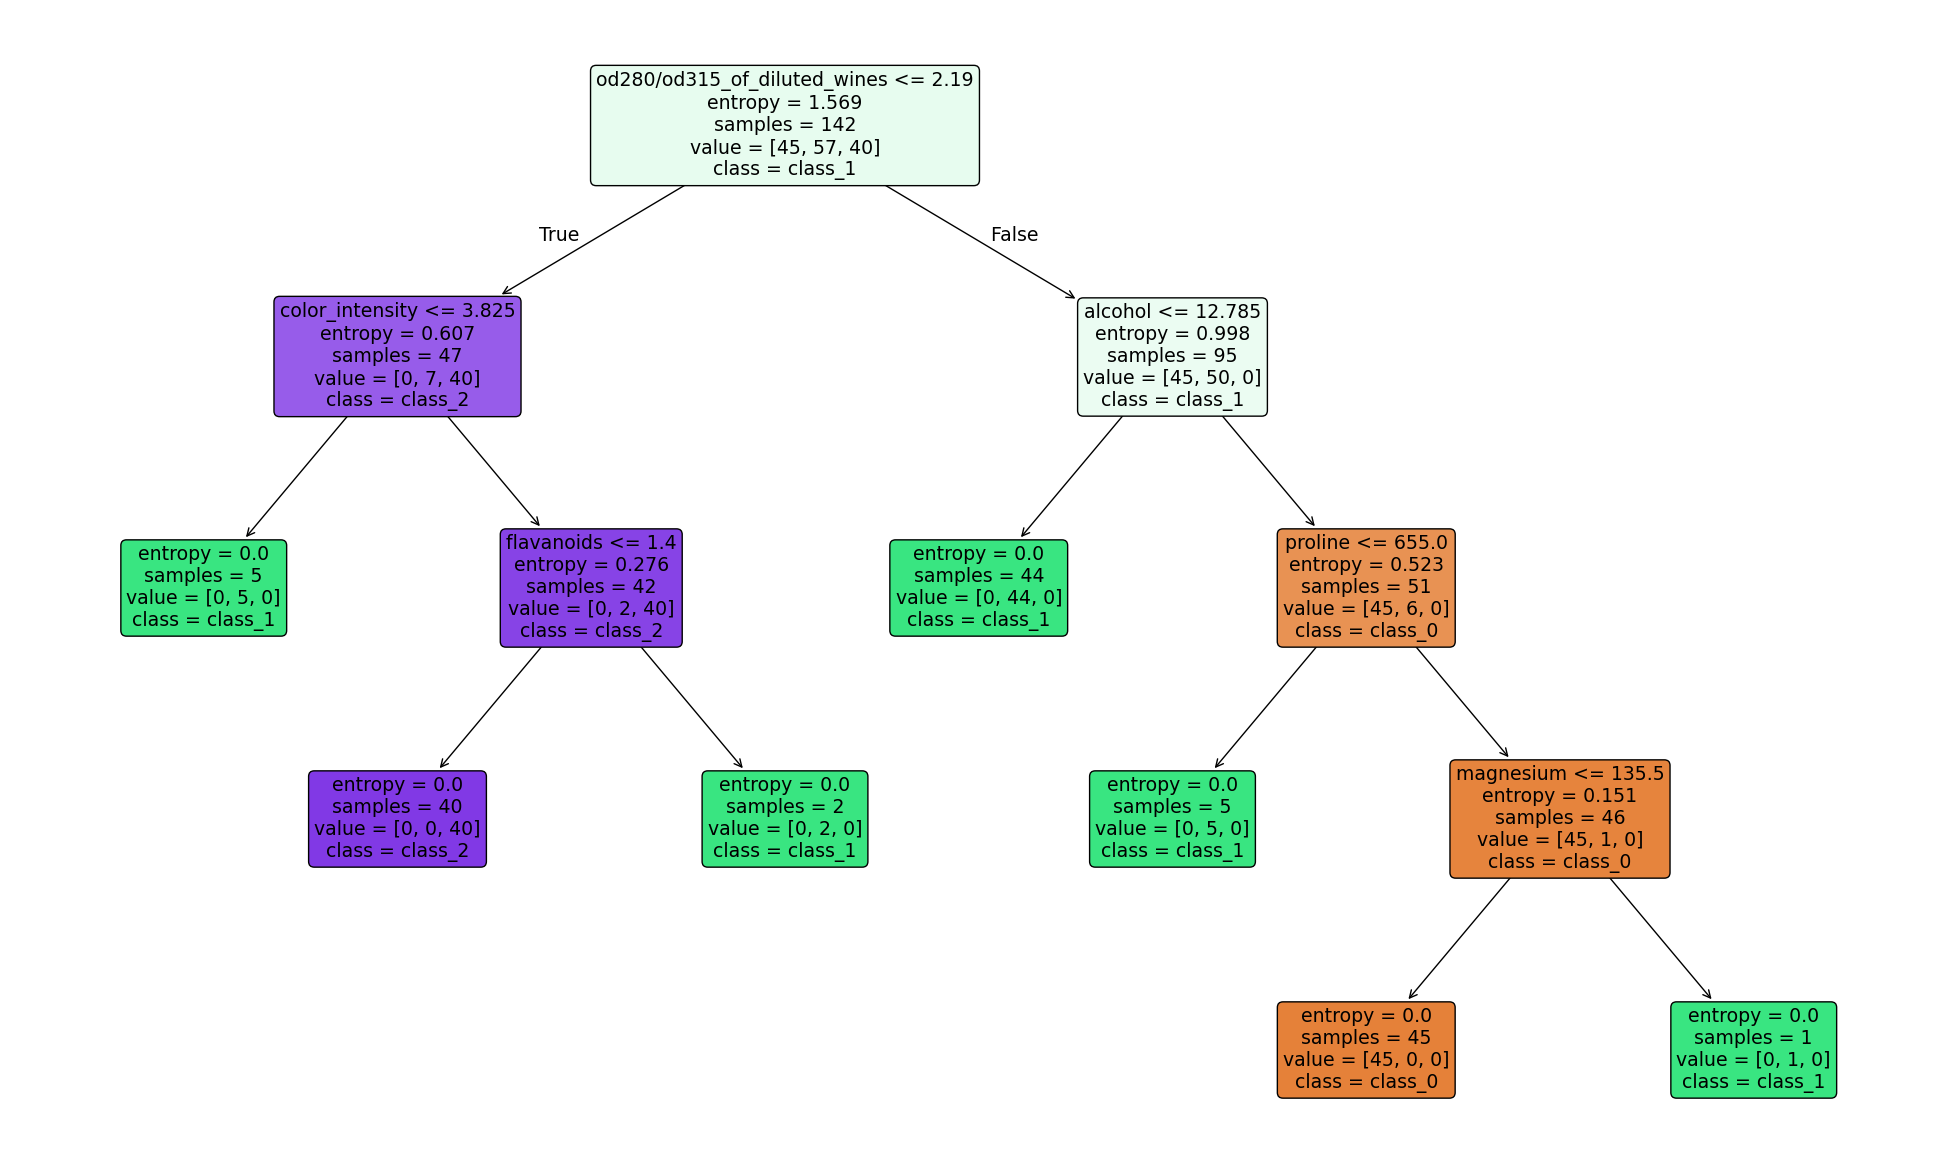

In [89]:
plt.figure(figsize=(25,15))

plot_tree(
    clf,
    feature_names=df.feature_names,
    class_names=df.target_names,
    filled=True,
    rounded=True
)

plt.show()